In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/covid_19_clean_complete.csv')

In [ ]:
df.shape

(49068, 10)

In [ ]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
a=(34404/49068)*100
a #more than 30 percent is null value

70.11494252873564

In [ ]:
df.drop('Province/State',axis=1,inplace=True)

In [ ]:
df.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country/Region  49068 non-null  object 
 1   Lat             49068 non-null  float64
 2   Long            49068 non-null  float64
 3   Date            49068 non-null  object 
 4   Confirmed       49068 non-null  int64  
 5   Deaths          49068 non-null  int64  
 6   Recovered       49068 non-null  int64  
 7   Active          49068 non-null  int64  
 8   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(3)
memory usage: 3.4+ MB


In [ ]:
df['Date']=pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.4+ MB


In [ ]:
df['Date'].describe()

,Date
count,49068
mean,2020-04-24 12:00:00
min,2020-01-22 00:00:00
25%,2020-03-08 18:00:00
50%,2020-04-24 12:00:00
75%,2020-06-10 06:00:00
max,2020-07-27 00:00:00


In [ ]:
Start_Date=df['Date'].min()
print("start date:", Start_Date)
End_Date=df['Date'].max()
print("end date:", End_Date)
noc=df['Country/Region'].nunique()
print('no of unique countries',noc)

start date: 2020-01-22 00:00:00
end date: 2020-07-27 00:00:00
no of unique countries 187


In [ ]:
global_daily=(
    df.groupby('Date')
    [['Confirmed','Deaths','Recovered','Active']]
    .sum()
    .reset_index()
)
global_daily

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,555,17,28,510
1,2020-01-23,654,18,30,606
2,2020-01-24,941,26,36,879
3,2020-01-25,1434,42,39,1353
4,2020-01-26,2118,56,52,2010
...,...,...,...,...,...
183,2020-07-23,15510481,633506,8710969,6166006
184,2020-07-24,15791645,639650,8939705,6212290
185,2020-07-25,16047190,644517,9158743,6243930
186,2020-07-26,16251796,648621,9293464,6309711


In [ ]:
global_daily.shape

(188, 5)

In [ ]:
#visualization(global confirmed cases trend)


In [ ]:
import plotly.express as px

In [ ]:
fig=px.line(
    global_daily,
    x='Date',
    y='Confirmed',
    title='Global Confirmed COVID-19 Cases over time'
)
fig.show()

<Axes: xlabel='Date', ylabel='Confirmed'>

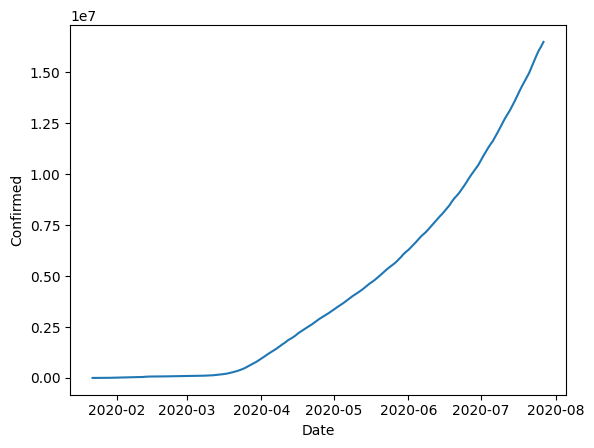

In [ ]:
import seaborn as sns # seaborn gives static data...thats why we prefer plotly in this project

sns.lineplot(
    data=global_daily,
    x='Date',
    y='Confirmed'
)

In [ ]:
#total confirmed cases is not sufficient
#how many new cases came each day, we have to take care of that as well
#lets find the daily new cases

In [ ]:
global_daily['New Cases']=global_daily['Confirmed'].diff()
global_daily

,Date,Confirmed,Deaths,Recovered,Active,New Cases
0,2020-01-22,555,17,28,510,NaN
1,2020-01-23,654,18,30,606,99.0
2,2020-01-24,941,26,36,879,287.0
3,2020-01-25,1434,42,39,1353,493.0
4,2020-01-26,2118,56,52,2010,684.0
...,...,...,...,...,...,...
183,2020-07-23,15510481,633506,8710969,6166006,282756.0
184,2020-07-24,15791645,639650,8939705,6212290,281164.0
185,2020-07-25,16047190,644517,9158743,6243930,255545.0
186,2020-07-26,16251796,648621,9293464,6309711,204606.0


In [ ]:
#we can see the Nan at the 1st row of New_cases column , lets handle this
global_daily['New Cases']=global_daily['New Cases'].fillna(0)
global_daily

,Date,Confirmed,Deaths,Recovered,Active,New Cases
0,2020-01-22,555,17,28,510,0.0
1,2020-01-23,654,18,30,606,99.0
2,2020-01-24,941,26,36,879,287.0
3,2020-01-25,1434,42,39,1353,493.0
4,2020-01-26,2118,56,52,2010,684.0
...,...,...,...,...,...,...
183,2020-07-23,15510481,633506,8710969,6166006,282756.0
184,2020-07-24,15791645,639650,8939705,6212290,281164.0
185,2020-07-25,16047190,644517,9158743,6243930,255545.0
186,2020-07-26,16251796,648621,9293464,6309711,204606.0


In [ ]:
fig1=px.line(
    global_daily,
    x='Date',
    y='New Cases',
    title='Global New COVID-19 Cases over time'
)
fig1.show()

In [ ]:
#this graph shows the rate of infection

In [ ]:
#visualization(globalRecovery case trend)


Recovery Rate=(Recovered/Confirmed)*100

In [ ]:
fig2=px.line(
    global_daily,
    x='Date',
    y='Recovered',
    title='Global Recovered COVID-19 Cases over time'
)
fig2.show()


In [ ]:
global_daily['New Recovered']=global_daily['Recovered'].diff()
global_daily['New Recovered']=global_daily['New Recovered'].fillna(0)
global_daily

,Date,Confirmed,Deaths,Recovered,Active,New Cases,New Recovered
0,2020-01-22,555,17,28,510,0.0,0.0
1,2020-01-23,654,18,30,606,99.0,2.0
2,2020-01-24,941,26,36,879,287.0,6.0
3,2020-01-25,1434,42,39,1353,493.0,3.0
4,2020-01-26,2118,56,52,2010,684.0,13.0
...,...,...,...,...,...,...,...
183,2020-07-23,15510481,633506,8710969,6166006,282756.0,169714.0
184,2020-07-24,15791645,639650,8939705,6212290,281164.0,228736.0
185,2020-07-25,16047190,644517,9158743,6243930,255545.0,219038.0
186,2020-07-26,16251796,648621,9293464,6309711,204606.0,134721.0


In [ ]:
fig3=px.line(
    global_daily,
    x='Date',
    y='New Recovered',
    title='Global New Recovered COVID-19 Cases over time'
)
fig3.show()


In [ ]:
global_daily['Recovery Rate']=(global_daily['Recovered']/global_daily['Confirmed'])*100
global_daily

,Date,Confirmed,Deaths,Recovered,Active,New Cases,New Recovered,Recovery Rate
0,2020-01-22,555,17,28,510,0.0,0.0,5.045045
1,2020-01-23,654,18,30,606,99.0,2.0,4.587156
2,2020-01-24,941,26,36,879,287.0,6.0,3.825717
3,2020-01-25,1434,42,39,1353,493.0,3.0,2.719665
4,2020-01-26,2118,56,52,2010,684.0,13.0,2.455146
...,...,...,...,...,...,...,...,...
183,2020-07-23,15510481,633506,8710969,6166006,282756.0,169714.0,56.161824
184,2020-07-24,15791645,639650,8939705,6212290,281164.0,228736.0,56.610347
185,2020-07-25,16047190,644517,9158743,6243930,255545.0,219038.0,57.073812
186,2020-07-26,16251796,648621,9293464,6309711,204606.0,134721.0,57.184228


In [ ]:
#recovery rate is not new recovered/new confirmed..it is total recovered/total confiremd

In [ ]:
fig4= px.line(
    global_daily,
    x='Date',
    y='Recovery Rate',
    title='Global Recovery Rate over time'
)
fig4.show()


In [ ]:
#death Rate

In [ ]:
global_daily['Death rate']=(global_daily['Deaths']/global_daily['Confirmed'])*100
global_daily

,Date,Confirmed,Deaths,Recovered,Active,New Cases,New Recovered,Recovery Rate,Death rate
0,2020-01-22,555,17,28,510,0.0,0.0,5.045045,3.063063
1,2020-01-23,654,18,30,606,99.0,2.0,4.587156,2.752294
2,2020-01-24,941,26,36,879,287.0,6.0,3.825717,2.763018
3,2020-01-25,1434,42,39,1353,493.0,3.0,2.719665,2.928870
4,2020-01-26,2118,56,52,2010,684.0,13.0,2.455146,2.644004
...,...,...,...,...,...,...,...,...,...
183,2020-07-23,15510481,633506,8710969,6166006,282756.0,169714.0,56.161824,4.084374
184,2020-07-24,15791645,639650,8939705,6212290,281164.0,228736.0,56.610347,4.050560
185,2020-07-25,16047190,644517,9158743,6243930,255545.0,219038.0,57.073812,4.016385
186,2020-07-26,16251796,648621,9293464,6309711,204606.0,134721.0,57.184228,3.991073


In [ ]:
fig5=px.line(
    global_daily,
    x='Date',
    y='Death rate',
    title='Global Death Rate over time'
)
fig5.show()

In [ ]:
#Recovery Rate vs detah rate
fig6=px.line(
    global_daily,
    x='Date',
    y=['Recovery Rate','Death rate'],
    title='Global Recovery Rate vs Death Rate over time'
)
fig6.show()


Prophet Forecasting

In [ ]:
#prophet only need 2 columns
#we'll use date and confirmed cases
#ds=date  (date stamp) and y= value to be predicted

In [ ]:
forecast_df=global_daily[['Date','Confirmed']]
forecast_df.columns=['ds','y']
forecast_df

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [ ]:
from prophet import Prophet
model= Prophet() #this contains rules but no data
model

In [ ]:
model.fit(forecast_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
model.history  #ds-date, y-actual confirmed class, floor- lower bound(default-0), t- time scaled from 0 to 1, y_scaled- normalized target value

,ds,y,floor,t,y_scaled
0,2020-01-22,555,0.0,0.000000,0.000034
1,2020-01-23,654,0.0,0.005348,0.000040
2,2020-01-24,941,0.0,0.010695,0.000057
3,2020-01-25,1434,0.0,0.016043,0.000087
4,2020-01-26,2118,0.0,0.021390,0.000129
...,...,...,...,...,...
183,2020-07-23,15510481,0.0,0.978610,0.941142
184,2020-07-24,15791645,0.0,0.983957,0.958203
185,2020-07-25,16047190,0.0,0.989305,0.973709
186,2020-07-26,16251796,0.0,0.994652,0.986124


In [ ]:
#floor, lower bound=0 by default, prophet assumes that it cannot be negative.
#t-- time scaled, prophet scales the date internally

In [ ]:
model.history.shape

(188, 5)

In [ ]:
#now we have to make future dates
future=model.make_future_dataframe(periods=7)
future.tail(10)

,ds
185,2020-07-25
186,2020-07-26
187,2020-07-27
188,2020-07-28
189,2020-07-29
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02
194,2020-08-03


In [ ]:
forecast= model.predict(future)

In [ ]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9613.287574,-133153.714515,81068.523473,-9613.287574,-9613.287574,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,-11063.558307,0.0,0.0,0.0,-20676.845881
1,2020-01-23,-6933.408775,-110598.061842,106370.926728,-6933.408775,-6933.408775,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,-1117.543863,0.0,0.0,0.0,-8050.952639
2,2020-01-24,-4253.529977,-103605.598905,113954.235918,-4253.529977,-4253.529977,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,10080.978737,0.0,0.0,0.0,5827.448760
3,2020-01-25,-1573.651178,-92319.926005,110801.872421,-1573.651178,-1573.651178,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,13750.326871,0.0,0.0,0.0,12176.675693
4,2020-01-26,1106.227621,-100329.406725,102706.173545,1106.227621,1106.227621,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,7298.791978,0.0,0.0,0.0,8405.019599


In [ ]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
190,2020-07-30,1.674392e+07,1.662858e+07,1.685544e+07
191,2020-07-31,1.695911e+07,1.686144e+07,1.706793e+07
192,2020-08-01,1.716677e+07,1.706285e+07,1.727980e+07
193,2020-08-02,1.736430e+07,1.725236e+07,1.747196e+07
194,2020-08-03,1.755889e+07,1.744339e+07,1.767134e+07


In [ ]:
from prophet.plot import plot_plotly
fig=plot_plotly(model,forecast)
fig.show()

In [ ]:
#top 10 countries by confirmed cases
latest=df[df['Date']==df['Date'].max()]
latest.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,Algeria,28.03390,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,Andorra,42.50630,1.521800,2020-07-27,907,52,803,52,Europe
48811,Angola,-11.20270,17.873900,2020-07-27,950,41,242,667,Africa


In [ ]:
top10_confirmed=(
    latest.sort_values('Confirmed',ascending=False)
    .head(10)
)
top10_confirmed[['Country/Region','Confirmed']]

,Country/Region,Confirmed
49030,US,4290259
48835,Brazil,2442375
48936,India,1480073
48992,Russia,816680
49005,South Africa,452529
48963,Mexico,395489
48986,Peru,389717
48854,Chile,347923
49028,United Kingdom,300111
48938,Iran,293606


In [ ]:
fig=px.bar(
    top10_confirmed,
    x='Country/Region',
    y='Confirmed',
    title='Top 10 Countries by Confirmed Cases'
)
fig.show()

In [ ]:
top10_deaths=(
    latest.sort_values('Deaths',ascending=False)
    .head(10)
)
top10_deaths[['Country/Region','Deaths']]

,Country/Region,Deaths
49030,US,148011
48835,Brazil,87618
49028,United Kingdom,45759
48963,Mexico,44022
48942,Italy,35112
48936,India,33408
48921,France,30096
49006,Spain,28432
48986,Peru,18418
48938,Iran,15912


In [ ]:
fig=px.bar(
    top10_deaths,
    x='Country/Region',
    y='Deaths',
    title='Top 10 Countries by Deaths Cases'
)
fig.show()

In [ ]:
#WHO analysis
region_data=(
    latest.groupby('WHO Region')
    [['Confirmed','Deaths','Recovered']]
    .sum()
    .reset_index()
)
region_data

,WHO Region,Confirmed,Deaths,Recovered
0,Africa,723207,12223,440645
1,Americas,8839286,342732,4468616
2,Eastern Mediterranean,1490744,38339,1201400
3,Europe,3299523,211144,1993723
4,South-East Asia,1835297,41349,1156933
5,Western Pacific,292428,8249,206770


In [ ]:
fig=px.pie(
    region_data,
    values='Confirmed',
    names='WHO Region',
    title='Confirmed Cases by WHO Region'
)
fig.show()


In [ ]:
#World Map
fig =px.choropleth(
    latest,
    locations='Country/Region',
    locationmode='country names',
    color='Confirmed',
    hover_name='Country/Region',
    title='Confirmed Cases by Country'
)
fig.show()